In [1]:
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import torch.nn.functional as F

rng = np.random.default_rng(42)

## Vanila-FNO

-, Step 1: load data \
-, Step 2: Training \
-, Step 3: Test performance & Tracking

#### Step 1: Load data

In [2]:
def I_stim(t, a_stim, d_stim, t_stim):
    return sum(
        a_stim_ * (t >= t_stim_) * (t <= t_stim_ + d_stim_) 
        for t_stim_, d_stim_, a_stim_ in zip(t_stim, d_stim, a_stim)
    )

T, dt = 400, 0.005                 # in ms
N = 300                            # number of samples
Nt = int(T / dt) + 1              # number of time steps
df = np.load(f"data/pr_n_data_{N}_T_400_dt_0.005_d_stim_0.88.npz")
sharp_jump_data = np.load(f"data/pr_n_data_{N}_one_sharp.npz")
t_stim, a_stim, d_stim = df['t_stim'], df['a_stim'], df['d_stim']

input_data = np.concatenate([a_stim, d_stim, t_stim], axis=1)  # (N, 3)
output_data = df["v"].squeeze(-1)
sharp_jump_all = sharp_jump_data['sharp_jump'][:, :-1]  # (300, 2)
t = np.arange(0, T + dt, dt).reshape(-1, 1)

train_idx = df['train_idx']
val_idx = df['val_idx']
test_idx = df['test_idx']

I_stim_all = np.stack([I_stim(t.squeeze(-1) , a_stim[i], d_stim[i], t_stim[i]) for i in range(N)],axis=0)  # (N, Nt)
# plotting_impluse_action_potential(t, output_data[0], I_stim(t, a_stim[0], d_stim[0], t_stim[0]), T=T)
print(f" input_data shape: {I_stim_all.shape}, output_data shape: {output_data.shape}, t shape: {t.shape}, sharp_jump shape: {sharp_jump_all.shape}")

 input_data shape: (300, 80001), output_data shape: (300, 80001), t shape: (80001, 1), sharp_jump shape: (300, 2)


#### Step 2: Training

In [9]:
# ---------------------------
# 1) Prepare data
# ---------------------------
X, Y = I_stim_all.astype(np.float32), output_data.astype(np.float32)    # (N, Nt), (N, Nt)
N, Nt = X.shape[0], t.shape[0]

### Subsample a smaller (t, x) gird for training (to speed up training and reduce memory)
points_per_step = 2000  # sampled (x,t) points per batch
t_idx = np.linspace(0, Nt - 1, points_per_step, dtype=int)
X, Y = X[:, t_idx], Y[:, t_idx]                 # (N, nx_sub)

# Build FNO input: [u0(x), x, t] -> (N, 3, nt_sub, nx_sub)
t_sub = t[t_idx, 0].astype(np.float32)                              # (nt_sub,)
t_grid = np.broadcast_to(t_sub[None, :], X.shape)                  # (N, nt_sub)
X_in = np.stack([X, t_grid], axis=1)                               # (N, 2, nt_sub)
Y_out = Y[:, None, :]                                              # (N, 1, nt_sub)

train_ds = TensorDataset(torch.from_numpy(X_in[train_idx]), torch.from_numpy(Y_out[train_idx]))
val_ds   = TensorDataset(torch.from_numpy(X_in[val_idx]), torch.from_numpy(Y_out[val_idx]))

train_loader = DataLoader(train_ds, batch_size=16, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=16, shuffle=False)

# ---------------------------
# 2) Define 2D FNO
# ---------------------------
class SpectralConv1d(nn.Module):
    def __init__(self, in_channels, out_channels, modes):
        super().__init__()
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.modes = modes
        scale = 1.0 / (in_channels * out_channels)
        self.weights = nn.Parameter(
            scale * torch.randn(in_channels, out_channels, modes, dtype=torch.cfloat)
        )

    def compl_mul1d(self, input, weights):
        return torch.einsum("bix,iox->box", input, weights)

    def forward(self, x):
        b, _, n = x.shape
        x_ft = torch.fft.rfft(x)
        out_ft = torch.zeros(b, self.out_channels, x_ft.size(-1), dtype=torch.cfloat, device=x.device)

        m = min(self.modes, x_ft.size(-1))
        out_ft[:, :, :m] = self.compl_mul1d(x_ft[:, :, :m], self.weights[:, :, :m])

        return torch.fft.irfft(out_ft, n=n)


class FNO1d(nn.Module):
    def __init__(self, in_channels=2, width=64, modes=16):
        super().__init__()
        self.fc0 = nn.Linear(in_channels, width)

        self.conv0 = SpectralConv1d(width, width, modes)
        self.conv1 = SpectralConv1d(width, width, modes)
        self.conv2 = SpectralConv1d(width, width, modes)
        self.conv3 = SpectralConv1d(width, width, modes)

        self.w0 = nn.Conv1d(width, width, 1)
        self.w1 = nn.Conv1d(width, width, 1)
        self.w2 = nn.Conv1d(width, width, 1)
        self.w3 = nn.Conv1d(width, width, 1)

        self.fc1 = nn.Linear(width, 128)
        self.fc2 = nn.Linear(128, 1)

    def forward(self, x):
        # x: (B, 2, nt_sub)
        x = x.permute(0, 2, 1)          # (B, nt_sub, 2)
        x = self.fc0(x)                 # (B, nt_sub, width)
        x = x.permute(0, 2, 1)          # (B, width, nt_sub)

        x = F.gelu(self.conv0(x) + self.w0(x))
        x = F.gelu(self.conv1(x) + self.w1(x))
        x = F.gelu(self.conv2(x) + self.w2(x))
        x = F.gelu(self.conv3(x) + self.w3(x))

        x = x.permute(0, 2, 1)          # (B, nt_sub, width)
        x = F.gelu(self.fc1(x))
        x = self.fc2(x)                 # (B, nt_sub, 1)
        return x.permute(0, 2, 1)       # (B, 1, nt_sub)


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = FNO1d(in_channels=2, width=80, modes=16).to(device)

optimizer = optim.Adam(model.parameters(), lr=2e-4, weight_decay=1e-6)
loss_fn = nn.MSELoss()

# ---------------------------
# 3) Train
# ---------------------------
epochs = 500
train_losses, val_losses = [], []

for epoch in range(1, epochs + 1):
    model.train()
    running_loss = 0.0

    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)

        optimizer.zero_grad()
        pred = model(xb)
        loss = loss_fn(pred, yb)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * xb.size(0)

    train_loss = running_loss / len(train_loader.dataset)
    train_losses.append(train_loss)

    model.eval()
    running_val = 0.0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            pred = model(xb)
            running_val += loss_fn(pred, yb).item() * xb.size(0)

    val_loss = running_val / max(len(val_loader.dataset), 1)
    val_losses.append(val_loss)

    if epoch % 20 == 0 or epoch == 1:
        print(f"Epoch {epoch:4d}/{epochs} | train_loss={train_loss:.6e} | val_loss={val_loss:.6e}")

# save checkpoint
checkpoint = {
    "model_state_dict": model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
    "epochs": epochs,
    "train_losses": train_losses,
    "val_losses": val_losses,
}
torch.save(checkpoint, f"checkpoints/vanilla_fno_checkpoint.pt")
print(f"Saved: vanilla_fno_checkpoint.pt")

Epoch    1/500 | train_loss=2.804422e+03 | val_loss=2.496387e+03
Epoch   20/500 | train_loss=7.386526e+02 | val_loss=7.352278e+02
Epoch   40/500 | train_loss=2.609565e+02 | val_loss=2.035655e+02
Epoch   60/500 | train_loss=1.740469e+02 | val_loss=1.478635e+02
Epoch   80/500 | train_loss=1.055674e+02 | val_loss=1.081547e+02
Epoch  100/500 | train_loss=8.344699e+01 | val_loss=7.407899e+01
Epoch  120/500 | train_loss=6.118946e+01 | val_loss=6.817519e+01
Epoch  140/500 | train_loss=5.889225e+01 | val_loss=5.046558e+01
Epoch  160/500 | train_loss=6.150328e+01 | val_loss=4.918980e+01
Epoch  180/500 | train_loss=3.165484e+01 | val_loss=3.209408e+01
Epoch  200/500 | train_loss=2.857387e+01 | val_loss=2.668915e+01
Epoch  220/500 | train_loss=2.653569e+01 | val_loss=2.809720e+01
Epoch  240/500 | train_loss=3.913315e+01 | val_loss=3.563518e+01
Epoch  260/500 | train_loss=1.953395e+01 | val_loss=1.840188e+01
Epoch  280/500 | train_loss=2.083581e+01 | val_loss=1.835512e+01
Epoch  300/500 | train_lo

#### Step 3: Test performance & Tracking

In [10]:
def error_analysis_all_t(pred, true, t, sharp_jump, window_size=5):
    abs_err = np.abs(pred - true)
    l1_loss = np.mean(abs_err)

    # Area near the sharp jump
    left_bound = np.maximum(sharp_jump[0] - window_size, 0)
    right_bound = np.minimum(t.shape[0], sharp_jump[1] + window_size + 1)
    l1_loss_near_sharp = np.mean(abs_err[left_bound:right_bound]) 

    return l1_loss, l1_loss_near_sharp, left_bound, right_bound

def error_analysis_dataset_test(model, I_stim_all_test, output_data_test, t_domain, sharp_jump_all, window_size=5):
    t_vec = t_domain.squeeze().astype(np.float32)  # (Nt,)
    t_grid = np.broadcast_to(t_vec[None, :], I_stim_all_test.shape)  

    l1_loss_all, l1_loss_near_discon_all = [], []

    for sample_id in range(I_stim_all_test.shape[0]):
        X_sample, Y_sample = I_stim_all_test[sample_id, :].astype(np.float32), output_data_test[sample_id, :].astype(np.float32)
        X_in = np.stack([X_sample, t_vec], axis=0)[None, :, :].astype(np.float32)
        
        # Predict
        with torch.no_grad():
            X_in = torch.from_numpy(X_in).to(device)
            pred_field = model(X_in).squeeze(0).squeeze(0).cpu().numpy()            # (Nt, Nx)

        # Error analysis
        l1_loss, l1_loss_near_discon, _, _  = error_analysis_all_t(pred_field, Y_sample, t, sharp_jump_all[sample_id], window_size=window_size)  
        l1_loss_all.append(l1_loss)
        l1_loss_near_discon_all.append(l1_loss_near_discon)

    return l1_loss_all, l1_loss_near_discon_all

def show_results(model, checkpoint, I_stim_all_test, output_data_test, t_domain, sharp_jump_all, sample_id):
    train_losses = checkpoint.get("train_losses", [])
    val_losses = checkpoint.get("val_losses", [])

    # Pick one validation sample (original dataset index)
    X_sample, Y_sample = I_stim_all_test[sample_id, :].astype(np.float32), output_data_test[sample_id, :].astype(np.float32)

    # Build FNO input for one sample: [u0(x), t] -> (1, 2, Nt)
    t_vec = t_domain.squeeze().astype(np.float32)  # (Nt,)
    t_grid = np.broadcast_to(t_vec[None, :], I_stim_all_test.shape)                        # (1, Nt)
    X_in = np.stack([X_sample, t_vec], axis=0)[None, :, :].astype(np.float32)

    # Predict
    with torch.no_grad():
        X_in = torch.from_numpy(X_in).to(device)
        pred_field = model(X_in).squeeze(0).squeeze(0).cpu().numpy()            # (Nt, Nx)

    # Error analysis
    _, _, left_bound, right_bound = error_analysis_all_t(pred_field, Y_sample, t, sharp_jump_all[sample_id], window_size=int(0.05 * Nt))  # 5% of total points on each side of the discontinuity

    fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=False)
    axes[0].plot(t, I_stim_all_test[sample_id], color="blue", label="Initial condition")
    axes[0].set_title("Input function u_0")
    axes[0].set_xlabel("x")
    axes[0].grid(True)
    axes[0].legend()

    axes[1].plot(t, pred_field, color="red", label="Pred")
    axes[1].plot(t, Y_sample, color="blue", linestyle="--", label="True")
    axes[1].axvline(t[left_bound], color="green", linestyle=":", label="Discontinuity region")
    axes[1].axvline(t[right_bound], color="green", linestyle=":")
    axes[1].set_xlabel("x")
    axes[1].set_ylabel("u")
    axes[1].grid(True)
    axes[1].legend()

    axes[2].plot(train_losses, label="Train")
    axes[2].plot(val_losses, label="Val")
    axes[2].set_yscale("log")
    axes[2].set_xlabel("Epoch")
    axes[2].set_title("Training Curve")
    axes[2].legend()
    axes[2].grid(True)


    plt.tight_layout()
    plt.show()

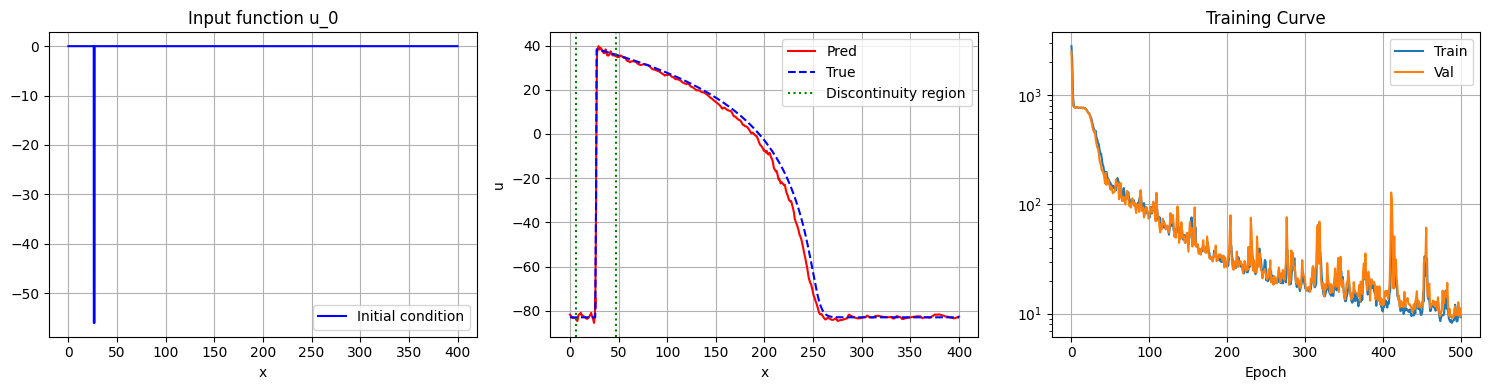

Total parameters: 446,257, trainable parameters: 446,257
L1 Loss (all points): 6.287, std: 7.049
L1 Loss (near discontinuity): 1.777, std: 0.856


In [11]:
# Load the trained Vanilla-FNO checkpoint
checkpoint = torch.load(f"checkpoints/vanilla_fno_checkpoint.pt", map_location=device, weights_only=False)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

I_stim_all_test, output_data_test, sharp_jump_test = I_stim_all[test_idx], output_data[test_idx], sharp_jump_all[test_idx]

l1_loss_all, l1_loss_near_discon_all = error_analysis_dataset_test(model, I_stim_all_test, output_data_test, t, sharp_jump_test, window_size=int(0.05 * Nt)) # 5% of total points on each side of the discontinuity
show_results(model, checkpoint, I_stim_all_test, output_data_test, t, sharp_jump_test, sample_id=2)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters: {total_params:,}, trainable parameters: {trainable_params:,}")
print(f"L1 Loss (all points): {np.mean(l1_loss_all):.3f}, std: {np.std(l1_loss_all):.3f}")
print(f"L1 Loss (near discontinuity): {np.mean(l1_loss_near_discon_all):.3f}, std: {np.std(l1_loss_near_discon_all):.3f}")